# Epidemic Duration by Viral Family

- **Summary**: This document visualizes the duration of epidemics across families.

- **Data Required:** `epidemics_marani_240816.xlsx`

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Sep 16, 2024

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm


from scipy.integrate import quad
from scipy.stats import genpareto
from scipy.optimize import minimize

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## 0. Prepare viral epidemic data

In [16]:
## Read epidemic data from Marani et al. 
df = pd.read_excel("data/epidemics_marani_240914_family.xlsx")


In [17]:
## Subset to epidemics from viral families
df_viral = df[df['family'].notna()].reset_index(drop=True)
df_viral = df_viral[df_viral['family'] != "misc"]

## Subset to epidemics with known severities
df_viral_known = df_viral[df_viral["severity_smu"] > 0].reset_index(drop=True)

## Subset to more recent era (1900-present)
yrmin = 1900
df_viral_known_1900 = df_viral_known[df_viral_known["year_start"] 
                                     >= yrmin].reset_index(drop=True)


In [26]:
## Print minimum severity to determine lower bound for x-axis
print(f'Minimum severity: {df_viral_known_1900["severity_smu"].min(): .5f} SMU')

## Print maximum severity to determine upper bound for x-axis
print(f'Maximum severity: {df_viral_known_1900["severity_smu"].max(): .5f} SMU')

## Print maximum duration to determine upper bound for y-axis
print(f'Maximum duration: {df_viral_known_1900["duration"].max()} years')


Minimum severity:  0.00016 SMU
Maximum severity:  170.82154 SMU
Maximum duration: 51 years


## 1. Plot duration against log severity within each family

In [32]:
## Display orthomyxoviridae family
df_orthomyxoviridae = df_viral_known_1900[df_viral_known_1900['family'] 
                                          == "orthomyxoviridae"].reset_index(drop=True)


df_orthomyxoviridae

,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic,family
0,"usa, yukon",1900,1900,1,0.100,1.633000e+06,0.000061,0.000612,influenza,viral,droplet,1,0,1,0,orthomyxoviridae
1,pandemic spanish flu,1918,1920,3,32000.000,1.873300e+06,17.082154,170.821545,influenza,viral,droplet,1,0,1,1,orthomyxoviridae
2,"salomon islands, ontong java",1926,1926,1,0.033,2.020467e+06,0.000016,0.000163,influenza,viral,droplet,1,0,1,0,orthomyxoviridae
3,pandemic of asian flu,1957,1958,2,2000.000,2.873306e+06,0.696062,6.960623,influenza,viral,droplet,1,0,1,1,orthomyxoviridae
4,hong kong flu,1968,1969,2,1000.000,3.551599e+06,0.281563,2.815633,influenza,viral,droplet,1,0,1,1,orthomyxoviridae
5,papua new guinea,1969,1970,2,3.000,3.625681e+06,0.000827,0.008274,influenza,viral,droplet,1,0,1,0,orthomyxoviridae
6,swine flu,2009,2009,1,284.500,6.872767e+06,0.041395,0.413953,influenza,viral,droplet,1,0,1,1,orthomyxoviridae
7,indian swine flu outbreak,2015,2015,1,2.000,7.379797e+06,0.000271,0.002710,influenza,viral,droplet,1,0,1,0,orthomyxoviridae


<Figure size 1800x500 with 0 Axes>

(0.0001, 1000.0)

(0.0, 60.0)

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Duration (years)')

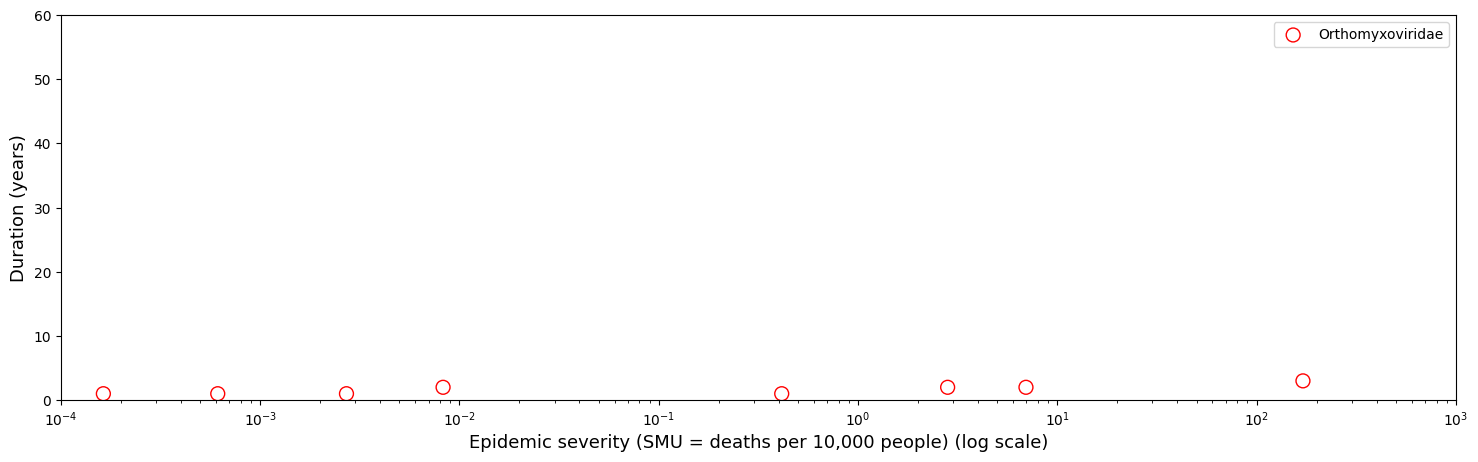

In [35]:
## Set figure size
plt.figure(figsize=(18, 5))

## Plot duration vs severity for epidemics  
plt.scatter(df_orthomyxoviridae['severity_smu'], 
            df_orthomyxoviridae['duration'], 
            edgecolor='red', facecolors='none', label='Orthomyxoviridae', s=100)

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-4, 1e3)

## Set y-axis limits
plt.ylim(0,60)


## Add title and axes labels
# plt.title('Censored  Durations of Threshold-Exceeding Respiratory Epidemics', fontsize = 12)
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Duration (years)', fontsize = 13)


## Display legend
plt.legend()

plt.show()



<Figure size 1800x500 with 0 Axes>

(0.0001, 1000.0)

(0.0, 55.0)

([<matplotlib.axis.YTick at 0x13d134950>,
 [Text(0, 0, '0'),
  Text(0, 5, '5'),
  Text(0, 10, '10'),
  Text(0, 15, '15'),
  Text(0, 20, '20'),
  Text(0, 25, '25'),
  Text(0, 30, '30'),
  Text(0, 35, '35'),
  Text(0, 40, '40'),
  Text(0, 45, '45'),
  Text(0, 50, '50'),
  Text(0, 55, '55')])

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Duration (years)')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


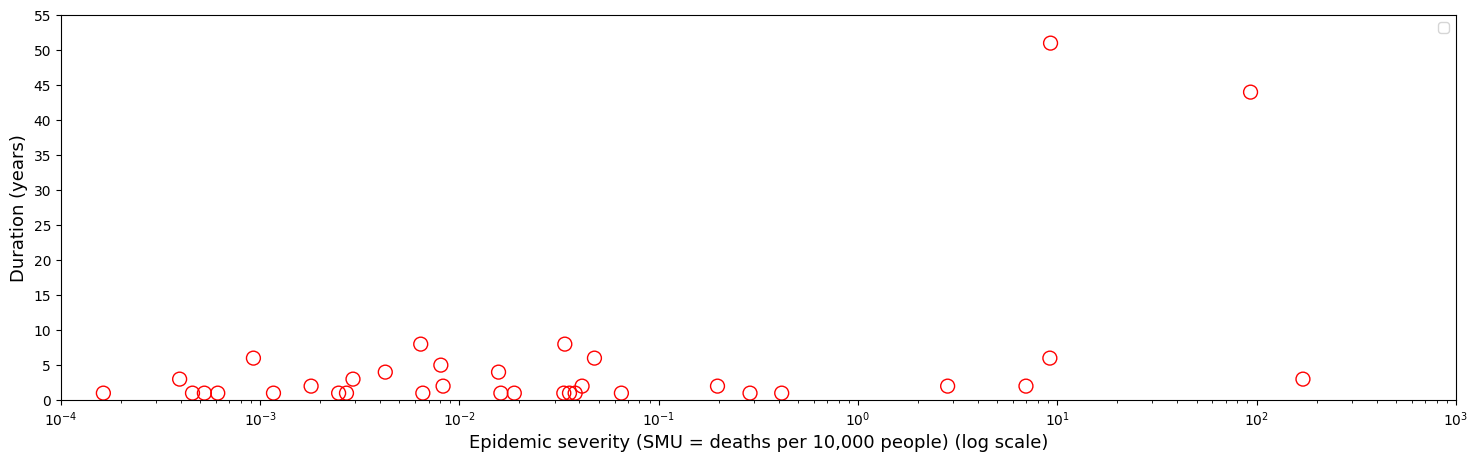

In [31]:
## Set figure size
plt.figure(figsize=(18, 5))

## Plot duration vs severity for viral epidemics
plt.scatter(df_viral_known_1900['severity_smu'], 
            df_viral_known_1900['duration'], 
            edgecolor='red', facecolors='none', s=100)

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-4, 1e3)

## Set y-axis limits
plt.ylim(0, 55)
plt.yticks(range(0,56,5))

## Add title and axes labels
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Duration (years)', fontsize=13)

## Display legend
plt.legend()

## Save graph as jpg file at 400 dpi
# plt.savefig('graphs/07_duration_1900_all.jpg', dpi=400, bbox_inches='tight')

plt.show()



In [14]:
## Read epidemic data from Marani et al. 
df = pd.read_excel("data/epidemics_marani_240816.xlsx")
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)

## Subset to respiratory viral epidemics
df_resp_viral = df[df['disease'].isin(['influenza', 'covid-19', 'mers', 'sars'])
                  ].reset_index(drop=True)


In [15]:
## Subset epidemic data to 1600-present
df_resp_viral_marani_inspired = df_resp_viral[(df_resp_viral["year_start"] >= 1600)].reset_index(drop=True)

## Set up severity threshold (SMU)
thresh = 0.01

## Subset to threshold-exceeding respiratory viral epidemics
df_marani_inspired_exceed = df_resp_viral_marani_inspired[df_resp_viral_marani_inspired['severity_smu'] >= thresh].reset_index(drop=True)


In [16]:
## Display
# df_marani_inspired_exceed

In [17]:
## Subset to influenza and coronavirus
df_marani_inspired_flu_exceed = df_marani_inspired_exceed[df_marani_inspired_exceed['disease'] == "influenza"]
df_marani_inspired_cov_exceed = df_marani_inspired_exceed[df_marani_inspired_exceed['disease'] == "covid-19"]

## 1. Visualize duration vs severity for 1600-present threshold-exceeding events

<Figure size 1800x500 with 0 Axes>

Text(1.149636714798124, 2.2, '1781')

Text(0.06974309260051942, 2.2, '1836')

Text(8.748030023773271, 2.2, '1889')

Text(170.8215448673464, 3.2, '1918')

...

Text(9.17312661498708, 6.2, '2019')

(0.01, 1000.0)

(0.0, 7.0)

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Duration (years)')

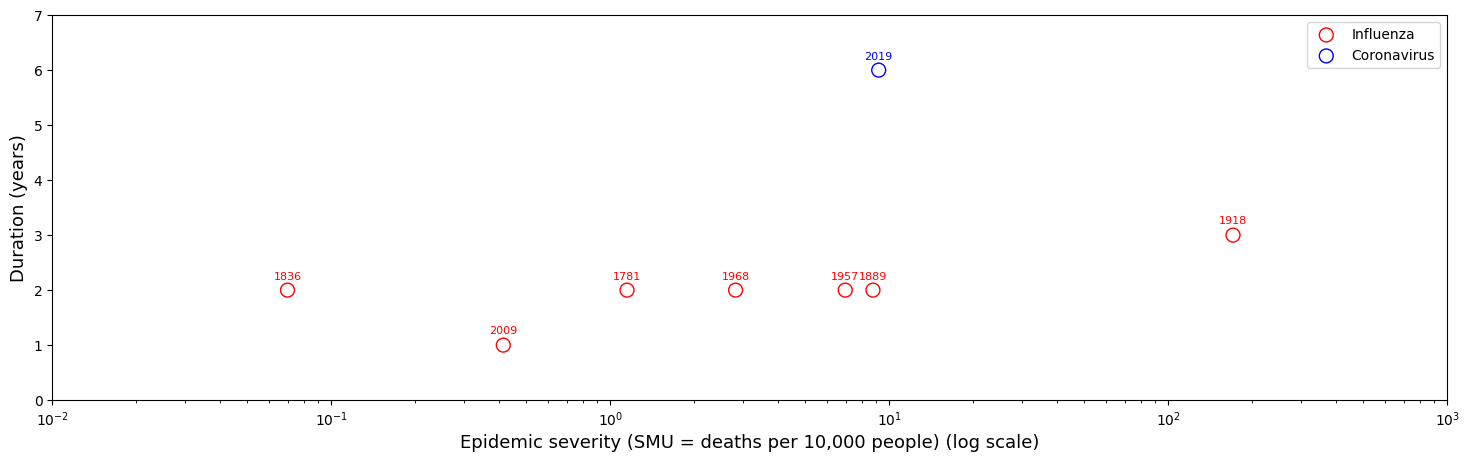

In [18]:
## Set figure size
plt.figure(figsize=(18, 5))

## Plot duration vs severity for influenza epidemics  
plt.scatter(df_marani_inspired_flu_exceed['severity_smu'], 
            df_marani_inspired_flu_exceed['duration'], 
            edgecolor='red', facecolors='none', label='Influenza', s=100)

for i in range(len(df_marani_inspired_flu_exceed)):
    plt.text(df_marani_inspired_flu_exceed['severity_smu'].iloc[i], 
             df_marani_inspired_flu_exceed['duration'].iloc[i] + 0.2,  ## Offset to above circle
             str(df_marani_inspired_flu_exceed['year_start'].iloc[i]), 
             ha='center', 
             fontsize = 8, color = 'red')

    
## Plot duration vs severity for coronavirus epidemics  
plt.scatter(df_marani_inspired_cov_exceed['severity_smu'], 
            df_marani_inspired_cov_exceed['duration'], 
            edgecolor='blue', facecolors='none', label='Coronavirus', s=100)

for i in range(len(df_marani_inspired_cov_exceed)):
    plt.text(df_marani_inspired_cov_exceed['severity_smu'].iloc[i], 
             df_marani_inspired_cov_exceed['duration'].iloc[i] + 0.2,  ## Offset to above circle
             str(df_marani_inspired_cov_exceed['year_start'].iloc[i]), 
             ha='center', 
             fontsize = 8, color = 'blue')

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-2, 1e3)

## Set y-axis limits
plt.ylim(0,7)

## Add title and axes labels
# plt.title('Censored  Durations of Threshold-Exceeding Respiratory Epidemics', fontsize = 12)
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Duration (years)', fontsize = 13)


## Display legend
plt.legend()

## Save graph as jpg file at 400 dpi
plt.savefig('graphs/07_duration_1600_exceed.jpg', dpi=400, bbox_inches = 'tight')

plt.show()


## 2. Visualize duration vs severity for 1900-present all known events

In [19]:
## Subset to all epidemics with known severities since 1900
df_resp_1900 = df_resp_viral[df_resp_viral['year_start'] >= 1900].reset_index(drop=True)
df_resp_known_1900 = df_resp_1900[df_resp_1900['severity_smu'] > 0].reset_index(drop=True)

## Print minimu severity to determine lower bound for x-axis
print(f'Minimum severity: {df_resp_known_1900["severity_smu"].min(): .5f} SMU')

Minimum severity:  0.00016 SMU


In [20]:
## Subset to influenza and coronavirus
df_flu_known_1900 = df_resp_known_1900[df_resp_known_1900['disease'] == "influenza"].reset_index(drop=True)
df_cov_known_1900 = df_resp_known_1900[df_resp_known_1900['disease'] != "influenza"].reset_index(drop=True)

<Figure size 1800x500 with 0 Axes>

Text(0.0006123698714023271, 1.2, '1900')

Text(170.8215448673464, 3.2, '1918')

Text(0.0001633286039528822, 1.2, '1926')

Text(6.960623059291283, 2.2, '1957')

...

Text(9.17312661498708, 6.2, '2019')

(0.0001, 1000.0)

(0.0, 7.0)

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Duration (years)')

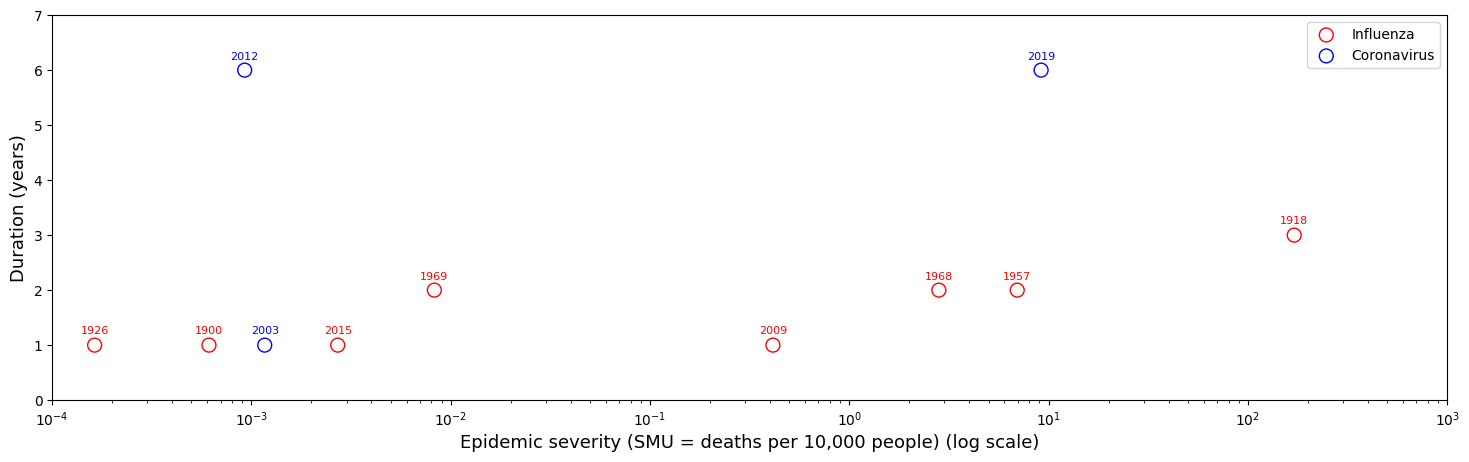

In [21]:
## Set figure size
plt.figure(figsize=(18, 5))

## Plot duration vs severity for influenza epidemics  
plt.scatter(df_flu_known_1900['severity_smu'], 
            df_flu_known_1900['duration'], 
            edgecolor='red', facecolors='none', label='Influenza', s=100)

for i in range(len(df_flu_known_1900)):
    plt.text(df_flu_known_1900['severity_smu'].iloc[i], 
             df_flu_known_1900['duration'].iloc[i] + 0.2,  ## Offset to above circle
             str(df_flu_known_1900['year_start'].iloc[i]), 
             ha='center', 
             fontsize=8, color='red')

## Plot duration vs severity for coronavirus epidemics  
plt.scatter(df_cov_known_1900['severity_smu'], 
            df_cov_known_1900['duration'], 
            edgecolor='blue', facecolors='none', label='Coronavirus', s=100)

for i in range(len(df_cov_known_1900)):
    plt.text(df_cov_known_1900['severity_smu'].iloc[i], 
             df_cov_known_1900['duration'].iloc[i] + 0.2,  ## Offset to above circle
             str(df_cov_known_1900['year_start'].iloc[i]), 
             ha='center', 
             fontsize=8, color='blue')

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-4, 1e3)

## Set y-axis limits
plt.ylim(0, 7)

## Add title and axes labels
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Duration (years)', fontsize=13)

## Display legend
plt.legend()

## Save graph as jpg file at 400 dpi
plt.savefig('graphs/07_duration_1900_all.jpg', dpi=400, bbox_inches='tight')

plt.show()


## 3. Visualize duration vs severity for 1900-present all known flu epidemics

In [22]:
## Set independent variable: natural log of flu severity
X = np.log(df_flu_known_1900['severity_smu'])

## Add a constant for the intercept term
X = sm.add_constant(X)

## Set dependent variable: duration
y = df_flu_known_1900['duration']

## Fit OLS
model = sm.OLS(y, X).fit()

## Print regression summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:               duration   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.580
Method:                 Least Squares   F-statistic:                     10.68
Date:                Mon, 16 Sep 2024   Prob (F-statistic):             0.0171
Time:                        14:29:19   Log-Likelihood:                -4.3611
No. Observations:                   8   AIC:                             12.72
Df Residuals:                       6   BIC:                             12.88
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.9185      0.193      9.961   

/Users/lichong/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [23]:
## Create a smooth range of severity values for OLS line
severity_range = np.logspace(np.log10(df_flu_known_1900['severity_smu'].min()), 
                             np.log10(df_flu_known_1900['severity_smu'].max()), 
                             100)  ## Generate 100 points in log scale

## Predict values using the OLS model
X_range_log = np.log(severity_range)  ## Log-transform the generated severity values
X_range_with_const = sm.add_constant(X_range_log)  ## Add constant intercept
predicted_duration = model.predict(X_range_with_const)  ## Predict duration


<Figure size 1800x500 with 0 Axes>

Text(0.0006123698714023271, 0.75, '1900')

Text(170.8215448673464, 2.75, '1918')

Text(0.0001633286039528822, 0.75, '1926')

Text(6.960623059291283, 1.75, '1957')

...

(0.0001, 341.5990584412921)

(0.0, 4.0)

([<matplotlib.axis.YTick at 0x13e8b0910>,
 [Text(0, 0, '0'),
  Text(0, 1, '1'),
  Text(0, 2, '2'),
  Text(0, 3, '3'),
  Text(0, 4, '4')])

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Duration (years)')

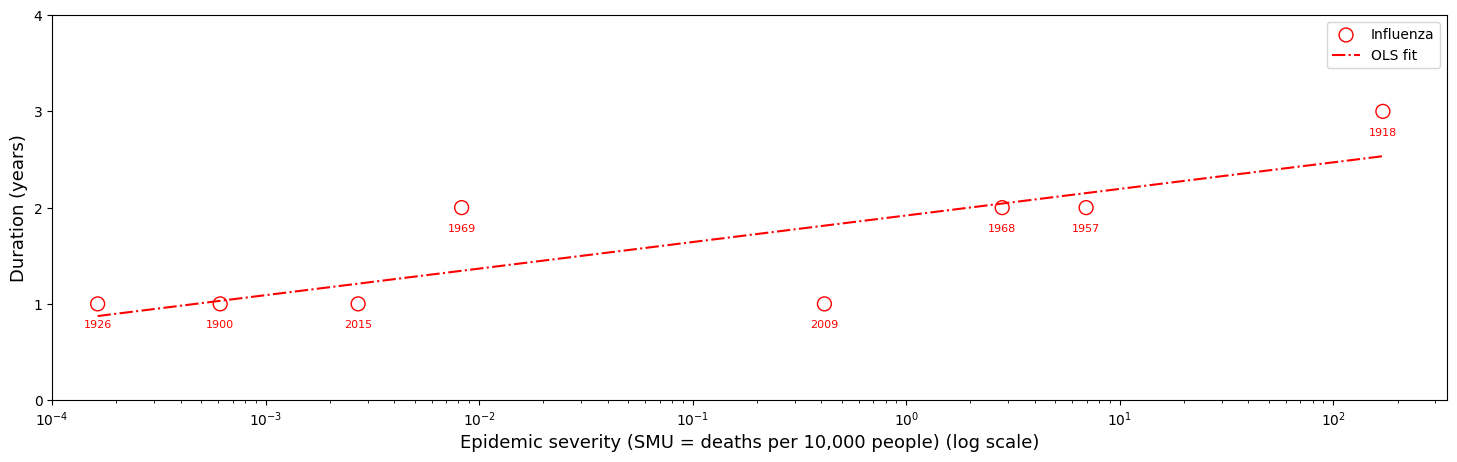

In [24]:
## Plot empirical and OLS relationships between duration and severity for flu
plt.figure(figsize=(18, 5))

## Plot duration vs severity for influenza epidemics  
plt.scatter(df_flu_known_1900['severity_smu'], 
            df_flu_known_1900['duration'], 
            edgecolor='red', facecolors='none', label='Influenza', s=100)

for i in range(len(df_flu_known_1900)):
    plt.text(df_flu_known_1900['severity_smu'].iloc[i], 
             df_flu_known_1900['duration'].iloc[i] - 0.25,  ## Offset to below circle
             str(df_flu_known_1900['year_start'].iloc[i]), 
             ha='center', fontsize=8, color='red')

## Plot the smooth OLS regression line
plt.plot(severity_range, predicted_duration, 
         color='red', linestyle="-.", label='OLS fit')

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-4,)
# plt.xlim(1e-4, 1e3)

## Set y-axis limits
plt.ylim(0, 4)
plt.yticks(range(0, 5, 1))

## Add title and axes labels
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Duration (years)', fontsize=13)

## Display legend
plt.legend()

## Save graph as jpg file at 400 dpi
plt.savefig('graphs/07_duration_ols_flu_1900_all.jpg', dpi=400, bbox_inches='tight')

plt.show()
